In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import torch
import matplotlib.pyplot as plt

# Load MEaSUREs Phase-Based Antarctica Ice Velocity Map

We use [MEaSUREs Phase-Based Antarctica Ice Velocity Map, Version 1](https://nsidc.org/data/nsidc-0754/versions/1)

Reference:
- *Mouginot, J., Rignot, E. & Scheuchl, B. (2019). MEaSUREs Phase-Based Antarctica Ice Velocity Map. (NSIDC-0754, Version 1). [Data Set]. Boulder, Colorado USA. NASA National Snow and Ice Data Center Distributed Active Archive Center. https://doi.org/10.5067/PZ3NJ5RXRH10. Date Accessed 10-02-2025.*

In [ ]:
# TODO define local path to ice velocity data
ice_vel = xr.load_dataset("/nsidc/antarctic_ice_vel_phase_map_v01.nc")

# Define new variable: speed V: sqrt(VX**2 + VY**2)
# hypot is numerically more stable than sqrt(VX**2 + VY**2)
ice_vel["V"] = np.hypot(ice_vel["VX"], ice_vel["VY"])

## Subset Ross region

In [ ]:
# import region bounds
from regions import ROSS_BOUNDS

# assign region bounds
x_min = ROSS_BOUNDS["x_min"]
x_max = ROSS_BOUNDS["x_max"]
y_min = ROSS_BOUNDS["y_min"]
y_max = ROSS_BOUNDS["y_max"]

# NOTE: x, y ordering!
ice_vel_ross = ice_vel.sel(
    x = slice(x_min, x_max), 
    y = slice(y_max, y_min))

ice_vel_ross

<xarray.Dataset> Size: 242MB
Dimensions:       (x: 2223, y: 2222)
Coordinates:
  * x             (x) float64 18kB -6e+05 -5.995e+05 ... 3.995e+05 4e+05
  * y             (y) float64 18kB -4.004e+05 -4.008e+05 ... -1.399e+06 -1.4e+06
    lat           (y, x) float64 40MB -83.37 -83.37 -83.38 ... -76.66 -76.66
    lon           (y, x) float64 40MB 236.3 236.3 236.2 ... 164.1 164.1 164.1
Data variables:
    coord_system  |S1 1B b''
    VX            (y, x) float32 20MB 12.16 12.11 11.48 10.77 ... nan nan nan
    VY            (y, x) float32 20MB 0.08527 0.174 0.1077 ... nan nan nan
    STDX          (y, x) float32 20MB 0.2943 0.1676 0.2148 ... nan nan nan
    STDY          (y, x) float32 20MB 0.7608 0.4851 0.683 1.092 ... nan nan nan
    ERRX          (y, x) float32 20MB 0.4791 0.3609 0.3734 ... nan nan nan
    ERRY          (y, x) float32 20MB 0.2238 0.1654 0.2066 ... nan nan nan
    CNT           (y, x) int32 20MB 15 15 15 15 15 15 15 15 ... 0 0 0 0 0 0 0 0
    SOURCE        (y, x) int8 5MB 3 3 3 3 3 3 3 3 3 1 1 ... 0 0 0 0 0 0 0 0 0 0
    V             (y, x) float32 20MB 12.16 12.11 11.48 10.77 ... nan nan nan
Attributes: (12/27)
    Conventions:               CF-1.6
    Metadata_Conventions:      CF-1.6, Unidata Dataset Discovery v1.0, GDS v2.0
    standard_name_vocabulary:  CF Standard Name Table (v22, 12 February 2013)
    id:                        v_mix.v8Jul2019.nc
    title:                     MEaSURES Antarctica Ice Velocity Map 450m spacing
    product_version:            
    ...                        ...
    time_coverage_start:       1995-01-01
    time_coverage_end:         2016-12-31
    project:                   NASA/MEaSUREs
    creator_name:              J. Mouginot
    comment:                    
    license:                   No restrictions on access or use.

# Interpolate the mask to subset region

data stays at og 450m grid. 

In [36]:
tighter_ice_shelf_mask = xr.load_dataarray("data/tighter_ice_shelf_mask.nc")

mask_for_ice_vel = tighter_ice_shelf_mask.interp(
    x = ice_vel_ross.x, 
    y = ice_vel_ross.y, 
    method = "nearest"
)

ice_vel_ross_on_target = ice_vel_ross.V.where(mask_for_ice_vel == 3)
ice_vel_ross_ds_on_target = ice_vel_ross.where(mask_for_ice_vel == 3)

# Load MODIS background

In [6]:
modis_ross = torch.load("data/modis/moa125_2014_hp1_v01_ross_with_grid_no_ocean.pt", weights_only = False)

# Visualise

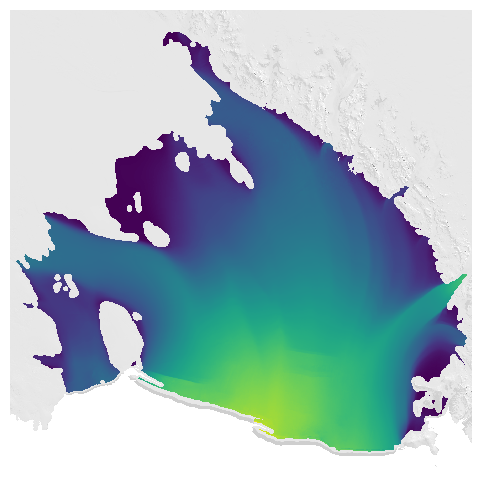

In [7]:
fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS as background (draw first)
ax.pcolormesh(
    modis_ross[0],
    modis_ross[1], 
    modis_ross[2],
    cmap = "gray",
    # softer greys
    vmin = -30_000, 
    vmax = 30_000,
    # as less saturated background
    alpha = 0.4,
    zorder = 0,
)

# 2) SMB on top (draw second)
pcm = ax.pcolormesh(
    ice_vel_ross_on_target.x,
    ice_vel_ross_on_target.y,
    ice_vel_ross_on_target,
    cmap = "viridis",
    # Fix these limits for consistency
    vmin = 0,
    vmax = 1200,
    shading = "auto",
    # 1.0 for full opacity & consistency
    alpha = 1.0,
    zorder = 1,
)

ax.set_aspect("equal")
ax.set_axis_off()

fig.savefig("figures/ice_vel_ross.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

# cmap

In [8]:
cmap = "viridis"
dpi = 300

# 1 x N gradient
grad = np.linspace(0, 1, 2048)[None, :]

fig = plt.figure(figsize = (6, 0.6), dpi = dpi)
ax = fig.add_axes([0, 0, 1, 1]) 
ax.imshow(grad, aspect = "auto", cmap = cmap)
ax.set_axis_off()

fig.savefig("figures/cmap/viridis_bar.png", dpi = dpi, transparent = True, bbox_inches = "tight", pad_inches = 0)
plt.close(fig)